# Fire Segmentation Training - U-Net Pipeline

**Trains pixel-level fire segmentation models**

## Models
- **Standard U-Net**: Full implementation with skip connections
- **Attention U-Net**: With attention gates for better focus
- **Lightweight U-Net**: Depthwise separable convolutions <2MB

## Configuration
- **Epochs**: 20
- **Batch Size**: 8 (smaller for segmentation)
- **Learning Rate**: 1e-4
- **Loss**: Combined (Dice + Focal + IoU)

## Expected Results
- **IoU**: >0.8
- **Dice**: >0.85
- **Pixel Accuracy**: >0.9

## 1. Setup and Imports

In [1]:
!pip install torch torchvision tqdm numpy matplotlib pillow scikit-learn opencv-python

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import torchvision.transforms as T
from PIL import Image
import numpy as np
import sys
import time
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2

# Add models to path
sys.path.append('../../models')
from unet_segmentation import UNet, LightweightUNet, SegmentationLoss, calculate_segmentation_metrics

print(" Fire Segmentation Training Pipeline")
print("=" * 50)

 Fire Segmentation Training Pipeline


## 2. Configuration

In [3]:
# Configuration
config = {
    'lr': 5e-5,
    'weight_decay': 1e-4,
    'epochs': 40,
    'batch_size': 4,  # Higher resolution with smaller batch
    'image_size': 320,
    'model_name': 'unet_attention',
    'adaptive_fire_threshold': True,
    'threshold_candidates': [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50],
}

# Data path
data_path = "../../data/processed/Output/Segmentation_Augmented"

print(f"Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")
print(f"\nData path: {data_path}")

Configuration:
  lr: 5e-05
  weight_decay: 0.0001
  epochs: 40
  batch_size: 4
  image_size: 320
  model_name: unet_attention
  adaptive_fire_threshold: True
  threshold_candidates: [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

Data path: ../../data/processed/Output/Segmentation_Augmented


## 3. Dataset and Data Loaders

In [4]:
class FireSegmentationDataset(Dataset):
    """Dataset for fire segmentation with images and masks"""

    def __init__(self, images_dir, masks_dir, transform=None, mask_transform=None):
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.transform = transform
        self.mask_transform = mask_transform

        # Get all image files
        self.image_files = sorted(list(self.images_dir.glob("*.jpg")))
        self.mask_files = sorted(list(self.masks_dir.glob("*.png")))

        # Ensure we have matching images and masks
        assert len(self.image_files) == len(self.mask_files), f"Mismatch: {len(self.image_files)} images, {len(self.mask_files)} masks"

        print(f"Found {len(self.image_files)} image-mask pairs")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Load image
        image_path = self.image_files[idx]
        image = Image.open(image_path).convert('RGB')

        # Load mask
        mask_path = self.mask_files[idx]
        mask = Image.open(mask_path).convert('L')  # Grayscale

        # Convert mask to binary (0 = background, 1 = fire)
        mask_array = np.array(mask)
        mask_array = (mask_array > 128).astype(np.uint8)

        # Apply transforms
        if self.transform:
            # Apply same random transform to both image and mask
            seed = torch.randint(0, 2**32, (1,)).item()

            torch.manual_seed(seed)
            image = self.transform(image)

            torch.manual_seed(seed)
            mask_pil = Image.fromarray(mask_array * 255)  # Convert back to 0-255 range for transforms
            if self.mask_transform:
                mask_tensor = self.mask_transform(mask_pil)
                # Convert back to class indices (0 or 1)
                mask_tensor = (mask_tensor > 0.5).long().squeeze(0)
            else:
                mask_tensor = torch.from_numpy(mask_array).long()
        else:
            image = T.ToTensor()(image)
            mask_tensor = torch.from_numpy(mask_array).long()

        # Create 4-channel input (RGB + thermal)
        # For now, use grayscale of RGB as thermal channel
        if image.shape[0] == 3:
            thermal = 0.299 * image[0] + 0.587 * image[1] + 0.114 * image[2]
            thermal = thermal.unsqueeze(0)
            image = torch.cat([image, thermal], dim=0)  # [4, H, W]

        return image, mask_tensor

# Create data loaders
def create_segmentation_data_loaders(data_path: str, batch_size: int = 8):
    """Create data loaders for segmentation"""

    image_size = int(config.get('image_size', 320))

    # Transforms
    image_transform = T.Compose([
        T.Resize((image_size, image_size)),
        T.RandomHorizontalFlip(0.5),
        T.RandomVerticalFlip(0.3),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    mask_transform = T.Compose([
        T.Resize((image_size, image_size), interpolation=T.InterpolationMode.NEAREST),
        T.ToTensor()
    ])

    val_image_transform = T.Compose([
        T.Resize((image_size, image_size)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_mask_transform = T.Compose([
        T.Resize((image_size, image_size), interpolation=T.InterpolationMode.NEAREST),
        T.ToTensor()
    ])

    # Data paths
    images_dir = Path(data_path) / "Images"
    masks_dir = Path(data_path) / "Masks"

    print(f"Loading segmentation data from:")
    print(f"  Images: {images_dir}")
    print(f"  Masks: {masks_dir}")

    # Build separate datasets so validation is never augmented.
    train_base_dataset = FireSegmentationDataset(
        images_dir=images_dir,
        masks_dir=masks_dir,
        transform=image_transform,
        mask_transform=mask_transform
    )
    val_base_dataset = FireSegmentationDataset(
        images_dir=images_dir,
        masks_dir=masks_dir,
        transform=val_image_transform,
        mask_transform=val_mask_transform
    )

    # Stratified image-level split by fire presence to stabilize train/val distribution.
    has_fire_flags = []
    for mask_path in train_base_dataset.mask_files:
        mask = Image.open(mask_path).convert('L')
        mask_array = np.array(mask)
        has_fire_flags.append(int((mask_array > 128).any()))

    has_fire_flags = np.array(has_fire_flags, dtype=np.int64)
    fire_indices = np.where(has_fire_flags == 1)[0]
    no_fire_indices = np.where(has_fire_flags == 0)[0]

    rng = np.random.default_rng(42)
    rng.shuffle(fire_indices)
    rng.shuffle(no_fire_indices)

    fire_train_size = int(0.8 * len(fire_indices))
    no_fire_train_size = int(0.8 * len(no_fire_indices))

    train_indices = np.concatenate([
        fire_indices[:fire_train_size],
        no_fire_indices[:no_fire_train_size]
    ])
    val_indices = np.concatenate([
        fire_indices[fire_train_size:],
        no_fire_indices[no_fire_train_size:]
    ])

    rng.shuffle(train_indices)
    rng.shuffle(val_indices)

    train_dataset = torch.utils.data.Subset(train_base_dataset, train_indices.tolist())
    val_dataset = torch.utils.data.Subset(val_base_dataset, val_indices.tolist())

    # WeightedRandomSampler for train set based on fire presence in masks
    train_fire_flags = has_fire_flags[train_indices].astype(np.float32)
    pos_count = int(train_fire_flags.sum())
    neg_count = len(train_fire_flags) - pos_count

    # Avoid divide-by-zero; if one class is absent, fall back to uniform sampling
    if pos_count > 0 and neg_count > 0:
        pos_weight = len(train_fire_flags) / (2.0 * pos_count)
        neg_weight = len(train_fire_flags) / (2.0 * neg_count)
        sample_weights = np.where(train_fire_flags > 0, pos_weight, neg_weight).astype(np.float32)
    else:
        sample_weights = np.ones(len(train_fire_flags), dtype=np.float32)

    train_sampler = WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )

    print(f"Image size: {image_size}x{image_size}")
    print(f"Train fire-image ratio: {train_fire_flags.mean():.4f} ({pos_count}/{len(train_fire_flags)})")
    print(f"Val fire-image ratio: {has_fire_flags[val_indices].mean():.4f} ({int(has_fire_flags[val_indices].sum())}/{len(val_indices)})")
    print(f"Sampler class weights -> fire: {sample_weights[train_fire_flags > 0][0] if pos_count > 0 else 1.0:.4f}, no_fire: {sample_weights[train_fire_flags == 0][0] if neg_count > 0 else 1.0:.4f}")

    # Windows + Jupyter safety: avoid worker deadlock at 0/xx batches.
    num_workers = 0
    pin_memory = torch.cuda.is_available()

    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        sampler=train_sampler,
        num_workers=num_workers,
        pin_memory=pin_memory
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory
    )

    print(f"Dataset sizes:")
    print(f"  Train: {len(train_dataset)}")
    print(f"  Val: {len(val_dataset)}")
    print(f"  DataLoader num_workers: {num_workers}")

    return train_loader, val_loader

# Create data loaders
print(" Loading segmentation data...")
train_loader, val_loader = create_segmentation_data_loaders(
    data_path, batch_size=config['batch_size']
)

 Loading segmentation data...
Loading segmentation data from:
  Images: ..\..\data\processed\Output\Segmentation_Augmented\Images
  Masks: ..\..\data\processed\Output\Segmentation_Augmented\Masks
Found 808 image-mask pairs
Found 808 image-mask pairs
Image size: 320x320
Train fire-image ratio: 1.0000 (646/646)
Val fire-image ratio: 1.0000 (162/162)
Sampler class weights -> fire: 1.0000, no_fire: 1.0000
Dataset sizes:
  Train: 646
  Val: 162
  DataLoader num_workers: 0


## 4. Model, Loss, and Optimizer Setup

Initialize segmentation model, training objective, optimizer, and scheduler.

In [5]:
# Reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Training configuration additions
config.setdefault('model_name', 'unet_attention')  # options: unet_standard, unet_attention, unet_lightweight
config.setdefault('save_dir', '../../models/trained/segmentation')
config.setdefault('plots_dir', '../../data/processed/Output/Segmentation')
config.setdefault('min_delta', 1e-4)
config.setdefault('max_grad_norm', 1.0)
config.setdefault('fire_threshold', 0.30)
config.setdefault('target_iou', 0.30)

# Original strict targets used for early stopping when all are achieved.
config.setdefault('stop_target_iou', 0.80)
config.setdefault('stop_target_dice', 0.85)
config.setdefault('stop_target_pixel_accuracy', 0.90)
config.setdefault('early_stop_on_targets', True)

save_dir = Path(config['save_dir'])
plots_dir = Path(config['plots_dir'])
save_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

# Build model variant
if config['model_name'] == 'unet_standard':
    model = UNet(n_channels=4, n_classes=2, bilinear=True, attention=False)
elif config['model_name'] == 'unet_attention':
    model = UNet(n_channels=4, n_classes=2, bilinear=True, attention=True)
elif config['model_name'] == 'unet_lightweight':
    model = LightweightUNet(n_channels=4, n_classes=2)
else:
    raise ValueError(f"Unknown model_name: {config['model_name']}")

model = model.to(device)
criterion = SegmentationLoss(
    dice_weight=0.35,
    focal_weight=0.15,
    iou_weight=0.50,
    focal_alpha=0.97,
    focal_gamma=2.0,
    min_fire_penalty=1.25,
)
optimizer = optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
# Keep scheduler args compatible across PyTorch versions (some versions do not support verbose)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

num_params = sum(p.numel() for p in model.parameters())
model_size_mb = num_params * 4 / (1024 ** 2)
print(f"Model: {config['model_name']}")
print(f"Parameters: {num_params:,}")
print(f"Approx model size: {model_size_mb:.2f} MB")
print(f"Training configured for full run: {config['epochs']} epochs")
print(f"Validation fire threshold: {config['fire_threshold']:.2f}")
print(f"Segmentation target IoU: {config['target_iou']:.2f}")
print(
    f"Early-stop strict targets: "
    f"IoU>={config['stop_target_iou']:.2f}, "
    f"Dice>={config['stop_target_dice']:.2f}, "
    f"PixelAcc>={config['stop_target_pixel_accuracy']:.2f}"
)
print(f"Early-stop on strict targets: {config['early_stop_on_targets']}")
print(f"Adaptive threshold: {config.get('adaptive_fire_threshold', True)}")

Using device: cpu
Model: unet_attention
Parameters: 17,615,150
Approx model size: 67.20 MB
Training configured for full run: 40 epochs
Validation fire threshold: 0.30
Segmentation target IoU: 0.30
Early-stop strict targets: IoU>=0.80, Dice>=0.85, PixelAcc>=0.90
Early-stop on strict targets: True
Adaptive threshold: True


## 5. Training and Validation Utilities

Define epoch-level train/validate functions and a full training loop that always runs all configured epochs (no early stopping).

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device, max_grad_norm=1.0):
    model.train()
    running_loss = 0.0

    progress = tqdm(loader, desc='Train', leave=False)
    for images, masks in progress:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()

        if max_grad_norm is not None and max_grad_norm > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        optimizer.step()

        running_loss += loss.item()
        progress.set_postfix({'loss': f'{loss.item():.4f}'})

    return running_loss / max(len(loader), 1)


def validate_one_epoch(
    model,
    loader,
    criterion,
    device,
    fire_threshold=0.30,
    adaptive_threshold=False,
    threshold_candidates=None,
):
    model.eval()
    running_loss = 0.0

    if threshold_candidates is None:
        threshold_candidates = [fire_threshold]

    threshold_stats = {
        float(t): {
            'iou': [],
            'dice': [],
            'pixel_accuracy': [],
            'pred_fire_ratio': [],
            'true_fire_ratio': [],
        }
        for t in threshold_candidates
    }

    with torch.no_grad():
        progress = tqdm(loader, desc='Val', leave=False)
        for images, masks in progress:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, masks)
            running_loss += loss.item()

            for t in threshold_stats.keys():
                metrics = calculate_segmentation_metrics(logits, masks, fire_threshold=t)
                threshold_stats[t]['iou'].append(metrics['iou'])
                threshold_stats[t]['dice'].append(metrics['dice'])
                threshold_stats[t]['pixel_accuracy'].append(metrics['pixel_accuracy'])
                threshold_stats[t]['pred_fire_ratio'].append(metrics['pred_fire_ratio'])
                threshold_stats[t]['true_fire_ratio'].append(metrics['true_fire_ratio'])

    mean_iou_by_t = {
        t: float(np.mean(stats['iou'])) if stats['iou'] else 0.0
        for t, stats in threshold_stats.items()
    }
    best_fire_threshold = max(mean_iou_by_t, key=mean_iou_by_t.get)

    selected_threshold = best_fire_threshold if adaptive_threshold else float(fire_threshold)
    selected_stats = threshold_stats[selected_threshold]

    return {
        'loss': running_loss / max(len(loader), 1),
        'iou': float(np.mean(selected_stats['iou'])) if selected_stats['iou'] else 0.0,
        'dice': float(np.mean(selected_stats['dice'])) if selected_stats['dice'] else 0.0,
        'pixel_accuracy': float(np.mean(selected_stats['pixel_accuracy'])) if selected_stats['pixel_accuracy'] else 0.0,
        'pred_fire_ratio': float(np.mean(selected_stats['pred_fire_ratio'])) if selected_stats['pred_fire_ratio'] else 0.0,
        'true_fire_ratio': float(np.mean(selected_stats['true_fire_ratio'])) if selected_stats['true_fire_ratio'] else 0.0,
        'selected_fire_threshold': selected_threshold,
        'best_fire_threshold': best_fire_threshold,
    }


def run_training(model, train_loader, val_loader, criterion, optimizer, scheduler, config, device):
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_iou': [],
        'val_dice': [],
        'val_pixel_accuracy': [],
        'val_pred_fire_ratio': [],
        'val_true_fire_ratio': [],
        'lr': [],
        'fire_threshold': [],
    }

    best_iou = -1.0
    best_epoch = -1
    best_state_dict = None

    current_fire_threshold = float(config.get('fire_threshold', 0.30))
    threshold_candidates = config.get('threshold_candidates', [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50])

    for epoch in range(1, config['epochs'] + 1):
        epoch_start = time.time()

        train_loss = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            max_grad_norm=config.get('max_grad_norm', 1.0),
        )

        val_metrics = validate_one_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
            fire_threshold=current_fire_threshold,
            adaptive_threshold=config.get('adaptive_fire_threshold', True),
            threshold_candidates=threshold_candidates,
        )

        # Keep chosen threshold for next epochs when adaptive mode is on.
        current_fire_threshold = float(val_metrics['selected_fire_threshold'])

        scheduler.step(val_metrics['iou'])

        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['val_iou'].append(val_metrics['iou'])
        history['val_dice'].append(val_metrics['dice'])
        history['val_pixel_accuracy'].append(val_metrics['pixel_accuracy'])
        history['val_pred_fire_ratio'].append(val_metrics['pred_fire_ratio'])
        history['val_true_fire_ratio'].append(val_metrics['true_fire_ratio'])
        history['lr'].append(current_lr)
        history['fire_threshold'].append(current_fire_threshold)

        improved = val_metrics['iou'] > (best_iou + config.get('min_delta', 1e-4))
        if improved:
            best_iou = val_metrics['iou']
            best_epoch = epoch
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        elapsed = time.time() - epoch_start
        print(
            f"Epoch {epoch:02d}/{config['epochs']} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val IoU: {val_metrics['iou']:.4f} | "
            f"Val Dice: {val_metrics['dice']:.4f} | "
            f"Val Acc: {val_metrics['pixel_accuracy']:.4f} | "
            f"Pred Fire: {val_metrics['pred_fire_ratio']:.4f} | "
            f"True Fire: {val_metrics['true_fire_ratio']:.4f} | "
            f"Thr: {current_fire_threshold:.2f} | "
            f"LR: {current_lr:.2e} | "
            f"Time: {elapsed:.1f}s"
        )

        # Early stop when all strict original targets are achieved.
        reached_strict_targets = (
            val_metrics['iou'] >= config.get('stop_target_iou', 0.80)
            and val_metrics['dice'] >= config.get('stop_target_dice', 0.85)
            and val_metrics['pixel_accuracy'] >= config.get('stop_target_pixel_accuracy', 0.90)
        )
        if config.get('early_stop_on_targets', True) and reached_strict_targets:
            # Ensure checkpoint from the target-reaching epoch is saved.
            if val_metrics['iou'] >= best_iou:
                best_iou = val_metrics['iou']
                best_epoch = epoch
                best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

            print("\nEarly stopping: strict segmentation targets reached.")
            print(
                f"Targets => IoU>={config.get('stop_target_iou', 0.80):.2f}, "
                f"Dice>={config.get('stop_target_dice', 0.85):.2f}, "
                f"PixelAcc>={config.get('stop_target_pixel_accuracy', 0.90):.2f}"
            )
            break

    if best_state_dict is None:
        best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_iou = history['val_iou'][-1] if history['val_iou'] else 0.0
        best_epoch = len(history['val_iou'])

    return {
        'history': history,
        'best_iou': best_iou,
        'best_epoch': best_epoch,
        'best_state_dict': best_state_dict,
    }

## 6. Train, Validate, and Save Best Model

Run full training loop, keep best checkpoint by validation IoU, and save training artifacts.

In [7]:
training_output = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    config=config,
    device=device,
)

history = training_output['history']
best_iou = training_output['best_iou']
best_epoch = training_output['best_epoch']

# Restore best model weights before saving/evaluation
model.load_state_dict(training_output['best_state_dict'])

model_path = save_dir / f"best_{config['model_name']}.pth"
checkpoint = {
    'model_name': config['model_name'],
    'model_state_dict': model.state_dict(),
    'config': config,
    'best_epoch': best_epoch,
    'best_val_iou': best_iou,
    'history': history,
}
torch.save(checkpoint, model_path)

print('\nTraining completed')
print(f"Best epoch: {best_epoch}")
print(f"Best validation IoU: {best_iou:.4f}")
print(f"Saved model: {model_path}")

Epoch 01/40 | Train Loss: 0.7493 | Val Loss: 0.3272 | Val IoU: 0.5829 | Val Dice: 0.7355 | Val Acc: 0.9963 | Pred Fire: 0.0075 | True Fire: 0.0068 | Thr: 0.50 | LR: 5.00e-05 | Time: 1236.3s


Epoch 02/40 | Train Loss: 0.6443 | Val Loss: 0.2657 | Val IoU: 0.6617 | Val Dice: 0.7957 | Val Acc: 0.9973 | Pred Fire: 0.0068 | True Fire: 0.0068 | Thr: 0.20 | LR: 5.00e-05 | Time: 1235.6s


Epoch 03/40 | Train Loss: 0.6209 | Val Loss: 0.2435 | Val IoU: 0.6880 | Val Dice: 0.8146 | Val Acc: 0.9976 | Pred Fire: 0.0064 | True Fire: 0.0068 | Thr: 0.25 | LR: 5.00e-05 | Time: 1105.9s


Epoch 04/40 | Train Loss: 0.6028 | Val Loss: 0.2252 | Val IoU: 0.7079 | Val Dice: 0.8285 | Val Acc: 0.9977 | Pred Fire: 0.0072 | True Fire: 0.0068 | Thr: 0.50 | LR: 5.00e-05 | Time: 1139.0s


Epoch 05/40 | Train Loss: 0.6410 | Val Loss: 0.2397 | Val IoU: 0.6926 | Val Dice: 0.8175 | Val Acc: 0.9976 | Pred Fire: 0.0067 | True Fire: 0.0068 | Thr: 0.20 | LR: 5.00e-05 | Time: 1185.7s


...

Epoch 24/40 | Train Loss: 0.5250 | Val Loss: 0.2683 | Val IoU: 0.6497 | Val Dice: 0.7798 | Val Acc: 0.9970 | Pred Fire: 0.0068 | True Fire: 0.0068 | Thr: 0.50 | LR: 6.25e-06 | Time: 1307.9s


Epoch 25/40 | Train Loss: 0.5164 | Val Loss: 0.2699 | Val IoU: 0.6417 | Val Dice: 0.7728 | Val Acc: 0.9968 | Pred Fire: 0.0073 | True Fire: 0.0068 | Thr: 0.50 | LR: 6.25e-06 | Time: 1172.7s


Epoch 26/40 | Train Loss: 0.5081 | Val Loss: 0.2631 | Val IoU: 0.6525 | Val Dice: 0.7811 | Val Acc: 0.9969 | Pred Fire: 0.0070 | True Fire: 0.0068 | Thr: 0.50 | LR: 3.13e-06 | Time: 1292.3s


Epoch 27/40 | Train Loss: 0.5180 | Val Loss: 0.2683 | Val IoU: 0.6437 | Val Dice: 0.7733 | Val Acc: 0.9968 | Pred Fire: 0.0070 | True Fire: 0.0068 | Thr: 0.50 | LR: 3.13e-06 | Time: 1276.2s


KeyboardInterrupt: 

## 7. Final Evaluation and Training Curves

Evaluate best checkpoint on validation set and plot loss/metrics for quick inspection.

Final validation metrics (best checkpoint loaded):
  Loss: 0.4699
  IoU: 0.2263
  Dice: 0.3556
  Pixel Accuracy: 0.9917
  Predicted Fire Pixel Ratio: 0.0060
  Ground Truth Fire Pixel Ratio: 0.0066

Segmentation target (IoU > 0.30): FAIL


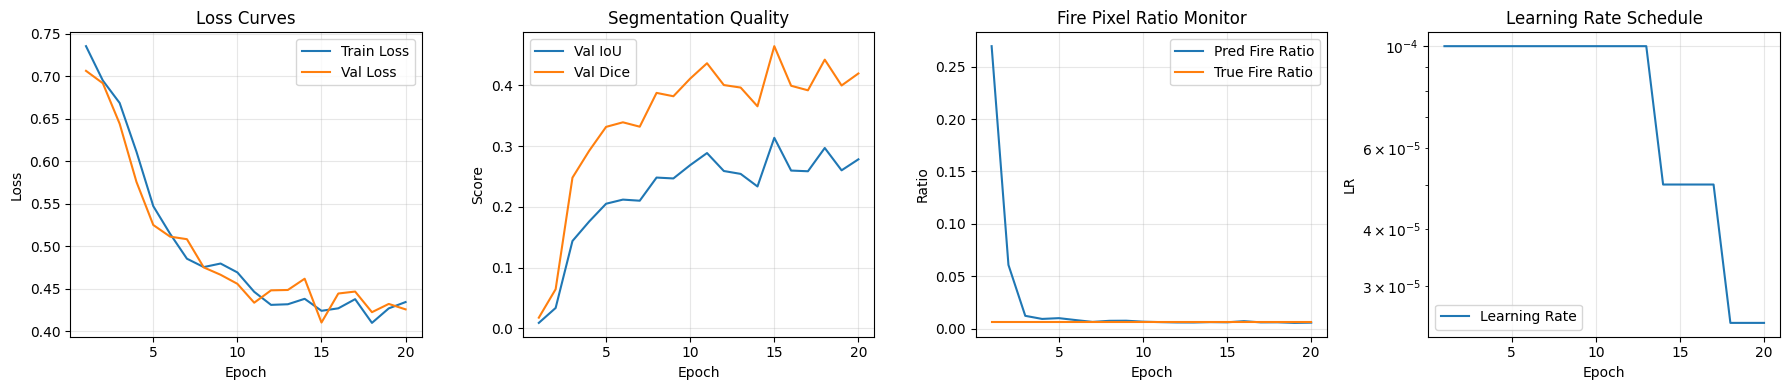

Saved training curves: ..\..\data\processed\Output\Segmentation\training_curves_unet_lightweight.png


In [ ]:
final_fire_threshold = (
    float(history['fire_threshold'][-1])
    if ('fire_threshold' in history and len(history['fire_threshold']) > 0)
    else float(config.get('fire_threshold', 0.30))
)

final_metrics = validate_one_epoch(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=device,
    fire_threshold=final_fire_threshold,
    adaptive_threshold=False,
)

print('Final validation metrics (best checkpoint loaded):')
print(f"  Fire threshold used: {final_fire_threshold:.2f}")
print(f"  Loss: {final_metrics['loss']:.4f}")
print(f"  IoU: {final_metrics['iou']:.4f}")
print(f"  Dice: {final_metrics['dice']:.4f}")
print(f"  Pixel Accuracy: {final_metrics['pixel_accuracy']:.4f}")
print(f"  Predicted Fire Pixel Ratio: {final_metrics['pred_fire_ratio']:.4f}")
print(f"  Ground Truth Fire Pixel Ratio: {final_metrics['true_fire_ratio']:.4f}")

# DICTA-oriented readiness check for segmentation quality
target_iou = config.get('target_iou', 0.30)
seg_ready = final_metrics['iou'] > target_iou
print(f"\nSegmentation target (IoU > {target_iou:.2f}): {'PASS' if seg_ready else 'FAIL'}")

# Plot training curves
epochs_ran = len(history['train_loss'])
epoch_axis = np.arange(1, epochs_ran + 1)

plt.figure(figsize=(20, 4))

plt.subplot(1, 5, 1)
plt.plot(epoch_axis, history['train_loss'], label='Train Loss')
plt.plot(epoch_axis, history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 5, 2)
plt.plot(epoch_axis, history['val_iou'], label='Val IoU')
plt.plot(epoch_axis, history['val_dice'], label='Val Dice')
plt.title('Segmentation Quality')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 5, 3)
plt.plot(epoch_axis, history['val_pred_fire_ratio'], label='Pred Fire Ratio')
plt.plot(epoch_axis, history['val_true_fire_ratio'], label='True Fire Ratio')
plt.title('Fire Pixel Ratio Monitor')
plt.xlabel('Epoch')
plt.ylabel('Ratio')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 5, 4)
plt.plot(epoch_axis, history['fire_threshold'], label='Fire Threshold')
plt.title('Adaptive Threshold')
plt.xlabel('Epoch')
plt.ylabel('Threshold')
plt.ylim(0.15, 0.55)
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 5, 5)
plt.plot(epoch_axis, history['lr'], label='Learning Rate')
plt.title('Learning Rate Schedule')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.yscale('log')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plot_path = plots_dir / f"training_curves_{config['model_name']}.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved training curves: {plot_path}")